
# Projeto Final de Inteligência Artificial

## Tema: Classificação de tumores mamários com Machine Learning

**Problema escolhido:** classificação binária.  
**Objetivo:** construir um pipeline completo de Machine Learning capaz de classificar amostras como **maligno** ou **benigno** usando medidas extraídas de imagens de células.

Este notebook aplica os principais conteúdos estudados ao longo da disciplina:

- análise exploratória dos dados;
- pré-processamento;
- normalização/padronização;
- treinamento de modelos supervisionados;
- comparação entre algoritmos;
- matriz de confusão;
- métricas de classificação;
- curva ROC e AUC;
- interpretação dos resultados.




## 1. Importação das bibliotecas

Nesta etapa são importadas as bibliotecas usadas para manipular os dados, gerar gráficos, treinar modelos e avaliar os resultados.


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score,
)
from sklearn.decomposition import PCA

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)



## 2. Carregamento e descrição do dataset

Foi utilizado o dataset **Breast Cancer Wisconsin**, disponível no próprio `scikit-learn`.  
Ele contém medidas numéricas calculadas a partir de imagens digitalizadas de células mamárias.

Cada amostra possui atributos como raio, textura, perímetro, área, suavidade e concavidade. O rótulo original informa se a amostra é **maligno** ou **benigno**.

Para este projeto, a classe positiva foi definida como:

$$
1 = \text{maligno}
$$

Essa escolha facilita a análise das métricas, pois em problemas de saúde normalmente o maior interesse é detectar corretamente os casos de risco.


In [ ]:

# Carregamento do dataset
cancer = load_breast_cancer()

X = pd.DataFrame(cancer.data, columns=cancer.feature_names)

# No sklearn: 0 = malignant e 1 = benign.
# Aqui invertemos para deixar malignant como classe positiva (1).
y = pd.Series((cancer.target == 0).astype(int), name='malignant')

df = X.copy()
df['diagnosis'] = y.map({1: 'malignant', 0: 'benign'})

display(df.head())
print(f'Total de amostras: {df.shape[0]}')
print(f'Total de atributos numéricos: {X.shape[1]}')
print('Classes do problema:', df['diagnosis'].unique())


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,malignant


Total de amostras: 569
Total de atributos numéricos: 30
Classes do problema: ['malignant' 'benign']



## 3. Análise exploratória dos dados

A análise inicial verifica o tamanho do dataset, a distribuição das classes, a existência de valores ausentes e possíveis duplicações.

Essa etapa é importante porque problemas como classes desbalanceadas, dados faltantes ou escalas muito diferentes podem prejudicar o treinamento dos modelos.


In [ ]:

print('Formato do dataset:', df.shape)
print('\nQuantidade por classe:')
display(df['diagnosis'].value_counts())

print('\nProporção por classe:')
display((df['diagnosis'].value_counts(normalize=True) * 100).round(2).astype(str) + '%')

missing_values = X.isna().sum().sum()
duplicated_rows = df.duplicated().sum()

print(f'\nValores ausentes encontrados: {missing_values}')
print(f'Linhas duplicadas encontradas: {duplicated_rows}')


Formato do dataset: (569, 31)

Quantidade por classe:


diagnosis
benign       357
malignant    212
Name: count, dtype: int64


Proporção por classe:


diagnosis
benign       62.74%
malignant    37.26%
Name: proportion, dtype: object


Valores ausentes encontrados: 0
Linhas duplicadas encontradas: 0


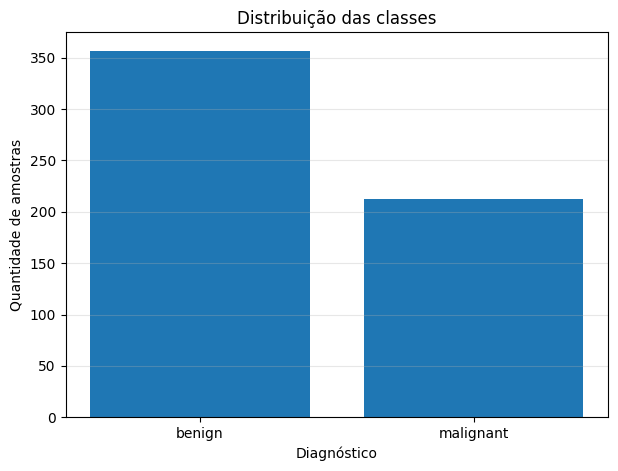

In [ ]:

# Distribuição das classes
class_counts = df['diagnosis'].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(class_counts.index, class_counts.values)
plt.title('Distribuição das classes')
plt.xlabel('Diagnóstico')
plt.ylabel('Quantidade de amostras')
plt.grid(axis='y', alpha=0.3)
plt.show()



### 3.1 Estatísticas descritivas

A tabela abaixo resume os atributos numéricos. É possível observar que as variáveis estão em escalas diferentes, por exemplo: algumas têm valores próximos de zero, enquanto outras têm valores na casa das centenas ou milhares.

Isso justifica o uso de padronização antes de treinar algoritmos sensíveis à escala, como Regressão Logística e KNN.


In [ ]:

display(X.describe().T[['mean', 'std', 'min', 'max']].round(3))


,mean,std,min,max
mean radius,14.127,3.524,6.981,28.110
mean texture,19.290,4.301,9.710,39.280
mean perimeter,91.969,24.299,43.790,188.500
mean area,654.889,351.914,143.500,2501.000
mean smoothness,0.096,0.014,0.053,0.163
mean compactness,0.104,0.053,0.019,0.345
mean concavity,0.089,0.080,0.000,0.427
mean concave points,0.049,0.039,0.000,0.201
mean symmetry,0.181,0.027,0.106,0.304
mean fractal dimension,0.063,0.007,0.050,0.097


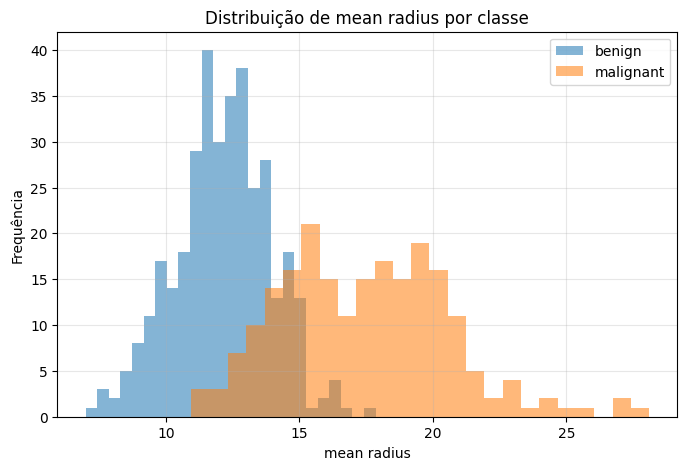

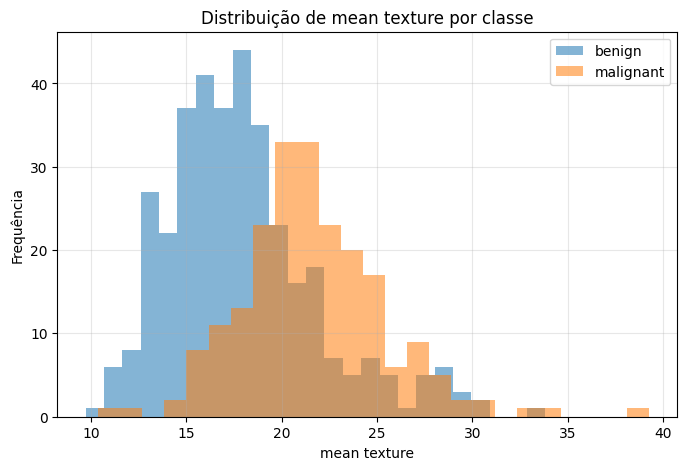

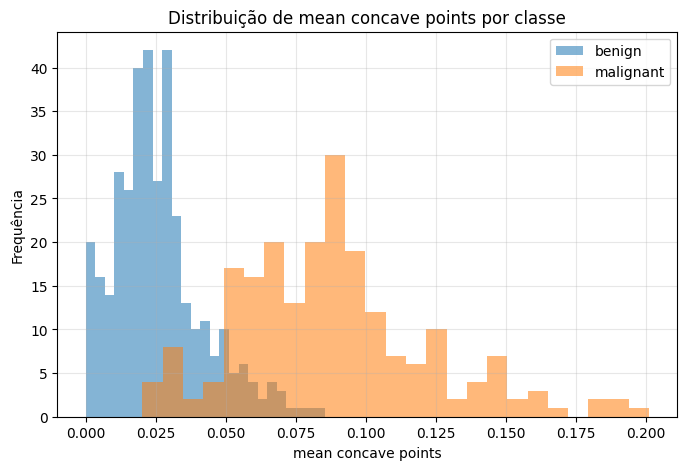

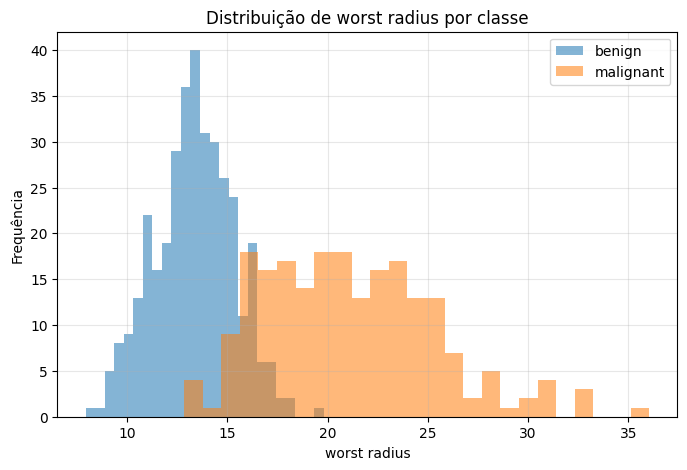

In [ ]:

# Visualização de algumas variáveis importantes separadas por classe
features_to_plot = ['mean radius', 'mean texture', 'mean concave points', 'worst radius']

for feature in features_to_plot:
    plt.figure(figsize=(8, 5))
    for label, group in df.groupby('diagnosis'):
        plt.hist(group[feature], bins=25, alpha=0.55, label=label)
    plt.title(f'Distribuição de {feature} por classe')
    plt.xlabel(feature)
    plt.ylabel('Frequência')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()



### 3.2 Relação dos atributos com a classe alvo

A correlação abaixo mostra quais variáveis possuem maior associação linear com o diagnóstico maligno.

Correlação positiva indica que valores maiores daquela variável tendem a estar associados à classe maligna. Correlação negativa indica tendência contrária.


,correlation_with_malignant
worst concave points,0.794
worst perimeter,0.783
mean concave points,0.777
worst radius,0.776
mean perimeter,0.743
worst area,0.734
mean radius,0.730
mean area,0.709
mean concavity,0.696
worst concavity,0.660


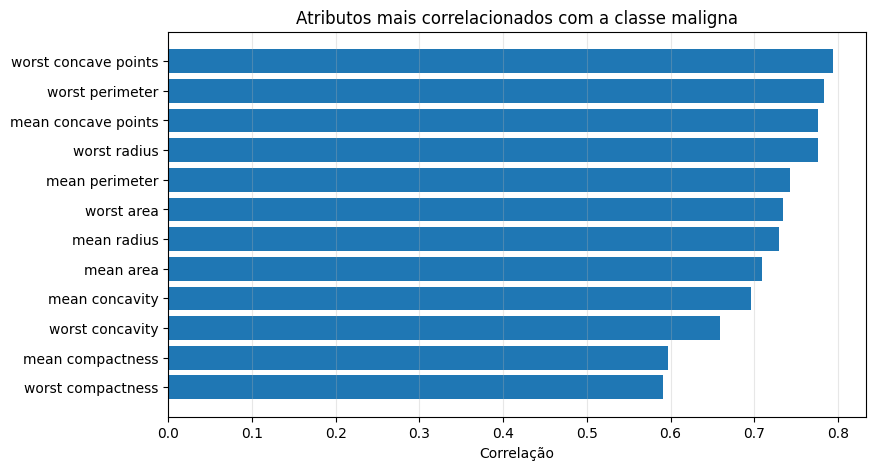

In [ ]:

corr_with_target = X.corrwith(y).sort_values(key=lambda s: s.abs(), ascending=False)
top_corr = corr_with_target.head(12)

display(top_corr.to_frame('correlation_with_malignant').round(3))

plt.figure(figsize=(9, 5))
plt.barh(top_corr.index[::-1], top_corr.values[::-1])
plt.title('Atributos mais correlacionados com a classe maligna')
plt.xlabel('Correlação')
plt.grid(axis='x', alpha=0.3)
plt.show()



## 4. Pré-processamento

O pré-processamento foi organizado em três partes:

1. separação entre treino e teste;
2. tratamento de valores ausentes com mediana, mesmo que o dataset não tenha valores faltantes;
3. padronização com `StandardScaler`, colocando os atributos em média próxima de 0 e desvio padrão próximo de 1.

A padronização é aplicada apenas com informações do conjunto de treino, evitando vazamento de dados do teste para o treinamento.


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print('Treino:', X_train.shape)
print('Teste:', X_test.shape)
print('\nDistribuição no treino:')
display(y_train.value_counts(normalize=True).rename({1: 'malignant', 0: 'benign'}).round(3))
print('\nDistribuição no teste:')
display(y_test.value_counts(normalize=True).rename({1: 'malignant', 0: 'benign'}).round(3))


Treino: (426, 30)
Teste: (143, 30)

Distribuição no treino:


malignant
benign       0.627
malignant    0.373
Name: proportion, dtype: float64


Distribuição no teste:


malignant
benign       0.629
malignant    0.371
Name: proportion, dtype: float64

In [ ]:

# Comparação antes e depois da padronização
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

comparison = pd.DataFrame({
    'original_mean': X_train[['mean radius', 'mean area', 'mean texture']].mean(),
    'original_std': X_train[['mean radius', 'mean area', 'mean texture']].std(),
    'scaled_mean': X_train_scaled[['mean radius', 'mean area', 'mean texture']].mean(),
    'scaled_std': X_train_scaled[['mean radius', 'mean area', 'mean texture']].std(),
})

display(comparison.round(3))


,original_mean,original_std,scaled_mean,scaled_std
mean radius,14.168,3.581,-0.0,1.001
mean area,660.076,361.429,0.0,1.001
mean texture,19.400,4.285,-0.0,1.001


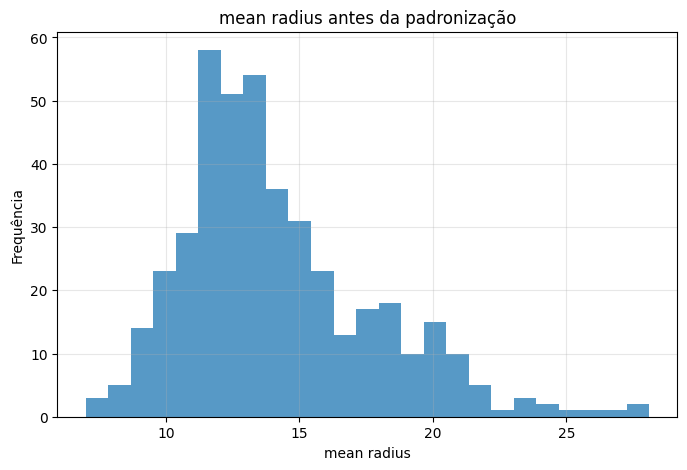

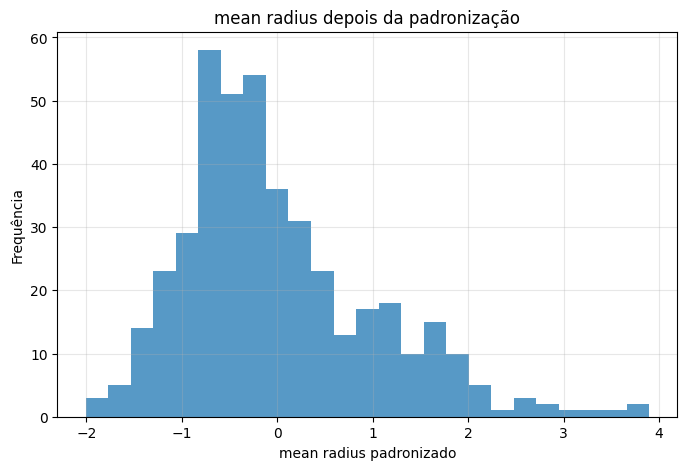

In [ ]:

# Visualmente, a distribuição mantém o formato, mas muda de escala.
feature = 'mean radius'

plt.figure(figsize=(8, 5))
plt.hist(X_train[feature], bins=25, alpha=0.75)
plt.title(f'{feature} antes da padronização')
plt.xlabel(feature)
plt.ylabel('Frequência')
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(X_train_scaled[feature], bins=25, alpha=0.75)
plt.title(f'{feature} depois da padronização')
plt.xlabel(f'{feature} padronizado')
plt.ylabel('Frequência')
plt.grid(alpha=0.3)
plt.show()



## 5. Modelagem

Foram comparados três algoritmos estudados na disciplina:

- **Regressão Logística:** boa para classificação binária, interpretável e gera probabilidades.
- **KNN:** classifica uma amostra olhando os vizinhos mais próximos; depende bastante da escala dos dados.
- **Árvore de Decisão:** modelo baseado em divisões sucessivas dos dados; fácil de visualizar e interpretar.

A Regressão Logística e o KNN usam padronização. A Árvore de Decisão não precisa de padronização, pois suas divisões são baseadas em limiares das variáveis.


In [ ]:

models = {
    'Logistic Regression': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE))
    ]),
    'KNN': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=7))
    ]),
    'Decision Tree': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=RANDOM_STATE))
    ])
}

results = []
trained_models = {}

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline

    y_pred = pipeline.predict(X_test)
    y_score = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision_malignant': precision_score(y_test, y_pred),
        'recall_malignant': recall_score(y_test, y_pred),
        'f1_malignant': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_score)
    })

metrics_df = pd.DataFrame(results).sort_values(by='f1_malignant', ascending=False)
display(metrics_df.round(4))


,model,accuracy,precision_malignant,recall_malignant,f1_malignant,roc_auc
0,Logistic Regression,0.9720,0.9804,0.9434,0.9615,0.9950
1,KNN,0.9720,1.0000,0.9245,0.9608,0.9870
2,Decision Tree,0.9441,0.9412,0.9057,0.9231,0.9232



## 6. Escolha do modelo final

Para este problema, o **recall da classe maligno** é uma métrica muito importante, porque um falso negativo significa que uma amostra maligna foi classificada como benigno.

Mesmo assim, também é necessário observar precisão e F1-score, para não escolher um modelo que acerte muitos malignos às custas de muitos falsos alarmes.

O modelo final será escolhido pelo melhor equilíbrio geral, usando principalmente o **F1-score da classe maligno** e a **AUC**.


In [ ]:

best_model_name = metrics_df.iloc[0]['model']
best_model = trained_models[best_model_name]

print(f'Modelo escolhido: {best_model_name}')
print('Motivo: melhor F1-score para a classe maligna entre os modelos testados.')


Modelo escolhido: Logistic Regression
Motivo: melhor F1-score para a classe maligna entre os modelos testados.



## 7. Avaliação detalhada do modelo escolhido

A matriz de confusão mostra os acertos e erros do modelo:

- **TN:** benigno previsto como benigno;
- **FP:** benigno previsto como maligno;
- **FN:** maligno previsto como benigno;
- **TP:** maligno previsto como maligno.

Em saúde, o erro mais crítico geralmente é o **FN**, pois representa um caso maligno não detectado pelo modelo.


<Figure size 600x500 with 0 Axes>

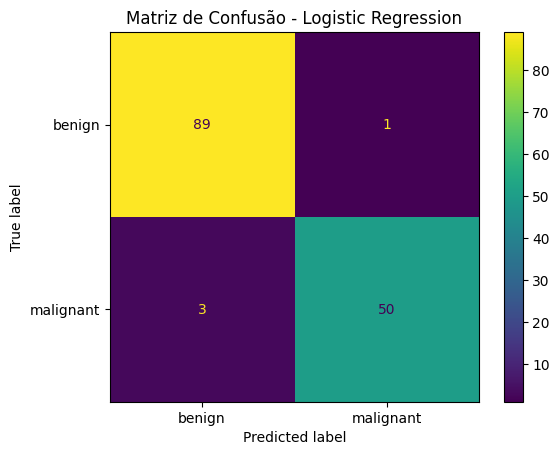

              precision    recall  f1-score   support

      benign       0.97      0.99      0.98        90
   malignant       0.98      0.94      0.96        53

    accuracy                           0.97       143
   macro avg       0.97      0.97      0.97       143
weighted avg       0.97      0.97      0.97       143



In [ ]:

y_pred_best = best_model.predict(X_test)
y_score_best = best_model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['benign', 'malignant']
)
disp.plot(values_format='d')
plt.title(f'Matriz de Confusão - {best_model_name}')
plt.grid(False)
plt.show()

print(classification_report(y_test, y_pred_best, target_names=['benign', 'malignant']))


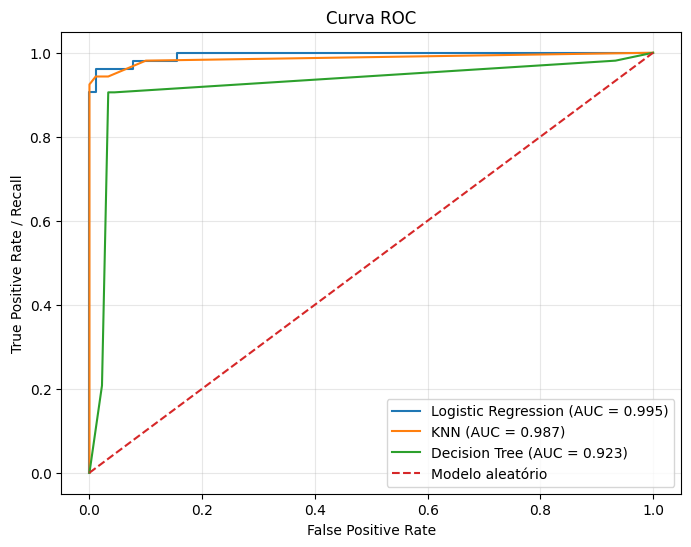

In [ ]:

# Curvas ROC para comparar a separação das classes nos três modelos
plt.figure(figsize=(8, 6))

for name, pipeline in trained_models.items():
    y_score = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_score)
    auc_value = roc_auc_score(y_test, y_score)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_value:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', label='Modelo aleatório')
plt.title('Curva ROC')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate / Recall')
plt.legend()
plt.grid(alpha=0.3)
plt.show()



## 8. Análise dos erros

Nesta etapa, são observados os casos em que o modelo errou.  
A análise dos erros ajuda a entender se os erros estão concentrados em amostras muito parecidas entre si ou em regiões difíceis de separar.


In [ ]:

error_analysis = X_test.copy()
error_analysis['real'] = y_test.map({0: 'benign', 1: 'malignant'})
error_analysis['predicted'] = pd.Series(y_pred_best, index=X_test.index).map({0: 'benign', 1: 'malignant'})
error_analysis['prob_malignant'] = y_score_best
error_analysis['correct'] = error_analysis['real'] == error_analysis['predicted']

errors = error_analysis[~error_analysis['correct']].copy()

print(f'Total de erros no teste: {len(errors)} de {len(X_test)} amostras')

display(errors[['real', 'predicted', 'prob_malignant', 'mean radius', 'mean texture', 'mean concave points', 'worst radius']].round(3))


Total de erros no teste: 4 de 143 amostras


,real,predicted,prob_malignant,mean radius,mean texture,mean concave points,worst radius
215,malignant,benign,0.433,13.86,16.93,0.056,15.75
455,benign,malignant,0.678,13.38,30.72,0.033,15.05
73,malignant,benign,0.080,13.80,15.79,0.051,16.57
190,malignant,benign,0.138,14.22,23.12,0.066,15.74


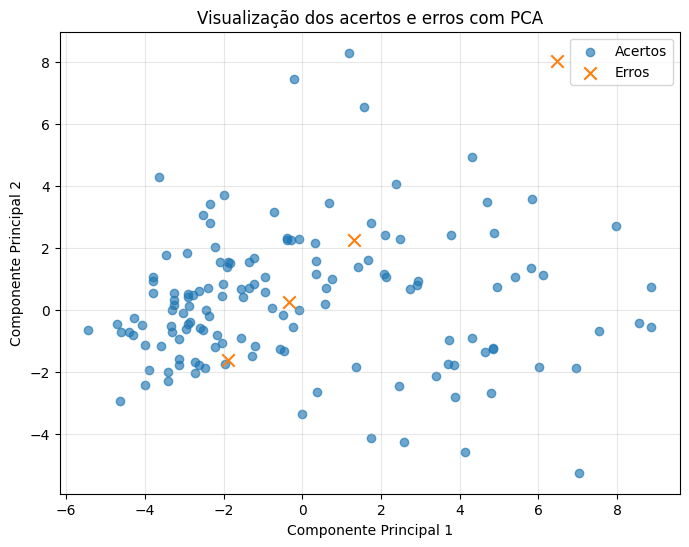

In [ ]:

# Projeção em 2D usando PCA para visualizar onde ficam os acertos e erros
preprocess_for_pca = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

X_test_prepared = preprocess_for_pca.fit_transform(X_train)
X_test_scaled_for_pca = preprocess_for_pca.transform(X_test)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca.fit(X_test_prepared)
X_test_pca = pca.transform(X_test_scaled_for_pca)

plt.figure(figsize=(8, 6))
correct_mask = error_analysis['correct'].values

plt.scatter(X_test_pca[correct_mask, 0], X_test_pca[correct_mask, 1], alpha=0.65, label='Acertos')
plt.scatter(X_test_pca[~correct_mask, 0], X_test_pca[~correct_mask, 1], marker='x', s=80, label='Erros')

plt.title('Visualização dos acertos e erros com PCA')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend()
plt.grid(alpha=0.3)
plt.show()



## 9. Interpretação do modelo

Como a Regressão Logística é um modelo interpretável, é possível analisar seus coeficientes caso ela esteja entre os modelos treinados.

Coeficientes positivos aumentam a probabilidade prevista de malignidade.  
Coeficientes negativos reduzem essa probabilidade.


,feature,coefficient,abs_coefficient
21,worst texture,1.3975,1.3975
10,radius error,1.3543,1.3543
28,worst symmetry,1.0550,1.0550
15,compactness error,-0.9846,0.9846
7,mean concave points,0.9802,0.9802
13,area error,0.9068,0.9068
23,worst area,0.8939,0.8939
26,worst concavity,0.8906,0.8906
20,worst radius,0.8896,0.8896
6,mean concavity,0.8744,0.8744


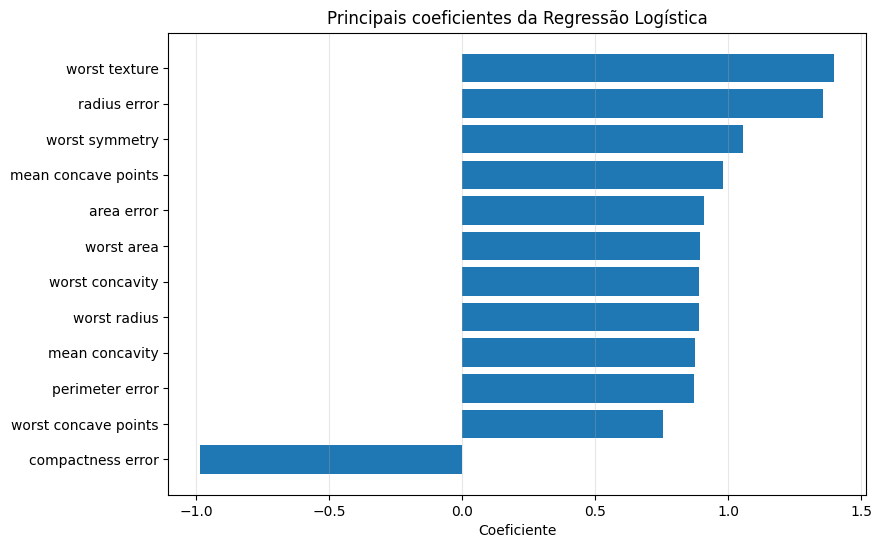

In [ ]:

logistic_pipeline = trained_models['Logistic Regression']
logistic_model = logistic_pipeline.named_steps['model']

coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': logistic_model.coef_[0]
})
coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coefficient', ascending=False)

display(coef_df.head(12).round(4))

plt.figure(figsize=(9, 6))
top_coef = coef_df.head(12).sort_values('coefficient')
plt.barh(top_coef['feature'], top_coef['coefficient'])
plt.title('Principais coeficientes da Regressão Logística')
plt.xlabel('Coeficiente')
plt.grid(axis='x', alpha=0.3)
plt.show()



## 10. Visualização da Árvore de Decisão

A árvore abaixo não precisa ser o melhor modelo, mas ajuda a entender como um algoritmo baseado em regras divide os dados.

A profundidade foi limitada para evitar uma árvore muito grande e difícil de interpretar.


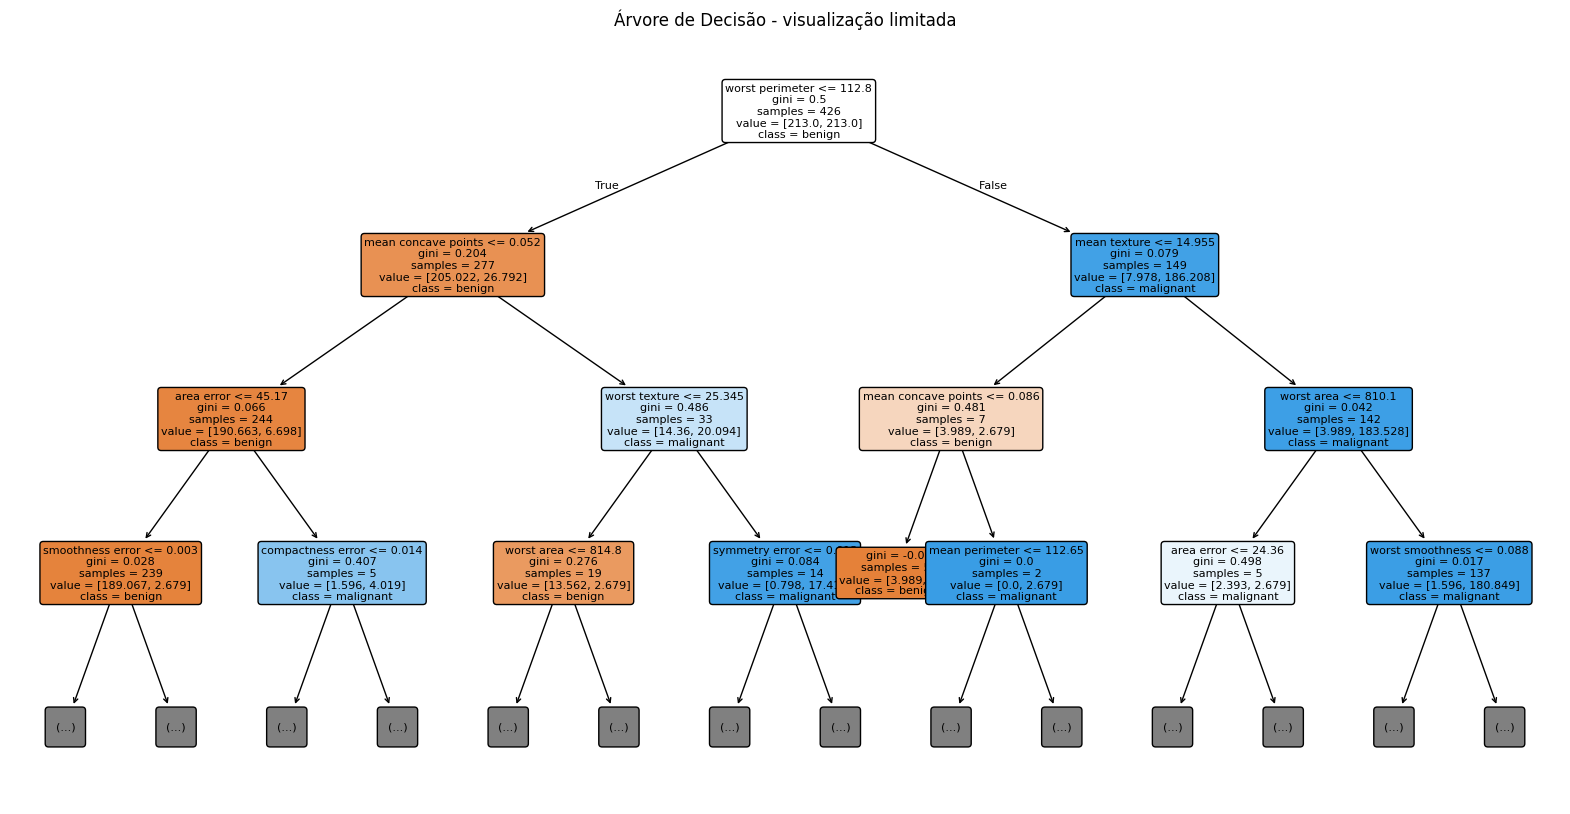

In [ ]:

dtree_model = trained_models['Decision Tree'].named_steps['model']

plt.figure(figsize=(20, 10))
plot_tree(
    dtree_model,
    feature_names=X.columns,
    class_names=['benign', 'malignant'],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.title('Árvore de Decisão - visualização limitada')
plt.show()



## 11. Conclusões

O projeto construiu um pipeline completo de Machine Learning para classificação binária. A partir dos resultados, é possível concluir:

1. **O modelo teve bom desempenho?**  
   Sim. Os modelos apresentaram bom desempenho geral, com destaque para o modelo escolhido pelo maior F1-score da classe maligno. A curva ROC também mostrou boa capacidade de separação entre as classes.

2. **O pré-processamento influenciou o resultado?**  
   Sim. A padronização foi importante porque os atributos estavam em escalas muito diferentes. Isso afeta principalmente algoritmos baseados em distância, como KNN, e modelos lineares, como Regressão Logística.

3. **O modelo seria útil em um cenário real?**  
   Poderia ser útil como ferramenta de apoio à triagem, principalmente por trabalhar com probabilidades e permitir análise dos casos mais suspeitos. Porém, em saúde, seria necessário validar o modelo com mais dados, acompanhamento de especialistas e testes em ambiente real antes de qualquer aplicação prática.

4. **Principal aprendizado do projeto:**  
   O desempenho de um modelo não depende apenas do algoritmo. A análise dos dados, o pré-processamento, a escolha das métricas e a interpretação dos erros são partes essenciais de um projeto de IA.


In [ ]:

# Resumo final automático
final_row = metrics_df.iloc[0]
print('Resumo do melhor modelo')
print('-' * 28)
print(f"Modelo: {final_row['model']}")
print(f"Accuracy: {final_row['accuracy']:.4f}")
print(f"Precision para maligno: {final_row['precision_malignant']:.4f}")
print(f"Recall para maligno: {final_row['recall_malignant']:.4f}")
print(f"F1-score para maligno: {final_row['f1_malignant']:.4f}")
print(f"AUC: {final_row['roc_auc']:.4f}")


Resumo do melhor modelo
----------------------------
Modelo: Logistic Regression
Accuracy: 0.9720
Precision para maligno: 0.9804
Recall para maligno: 0.9434
F1-score para maligno: 0.9615
AUC: 0.9950
